# Answers for week 6
* Name: Matthias van Weeren
* Username: mbweeren
* Student snumber: s6457002
* Group: AS2

### Q6.1 (session quiz)

In [1]:
from astropy.io import fits

hdulist = fits.open('/Users/users/mbweeren/PROGNUM-repo/Task6/m101.fits')
hdulist.info()

Filename: /Users/users/mbweeren/PROGNUM-repo/Task6/m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   


- There are two HDU's with indexes 0 and 1.
- The HDU with index 0 contains the data, which we can see from the dimension column, in which the amount of pixels of the picture is located.
- Under 'Format' we can see that the number type of this data is a 16 bits integer.

In [2]:
hdr = hdulist[0].header
hdr[:5]

SIMPLE  =                    T /FITS header                                     
BITPIX  =                   16 /No.Bits per pixel                               
NAXIS   =                    2 /No.dimensions                                   
NAXIS1  =                  530 /Length X axis                                   
NAXIS2  =                  530 /Length Y axis                                   

The value of BITPIX corresponds to my previous answer: 16 bits (integer).

In [3]:
dat = hdulist[0].data
print("Shape of numpy array:", dat.shape)
print("Dtype of numpy array:", dat.dtype)

Shape of numpy array: (530, 530)
Dtype of numpy array: >i2


This corresponds to the data found when using info and header (behind the NAXIS keywords). The dtype also corresponds to the value of BITPIX, as >i2 corresponds to integer 16 bits (i = integer and 2 x 8 = 16 bits).

In [4]:
import numpy as np
from scipy import stats

flat_data = dat.flatten()
modus_result = stats.mode(flat_data)

print(f" minimum = {np.min(flat_data)}\n",
    f"maximum = {np.max(flat_data)}\n",
    f"mean = {np.mean(flat_data)}\n",
    f"std = {np.std(flat_data)}\n",
    f"median = {np.median(flat_data)}\n",
    f"mode = {modus_result}")

 minimum = 1507
 maximum = 15752
 mean = 4795.924268422927
 std = 1848.2526085366376
 median = 4102.0
 mode = ModeResult(mode=3551, count=876)


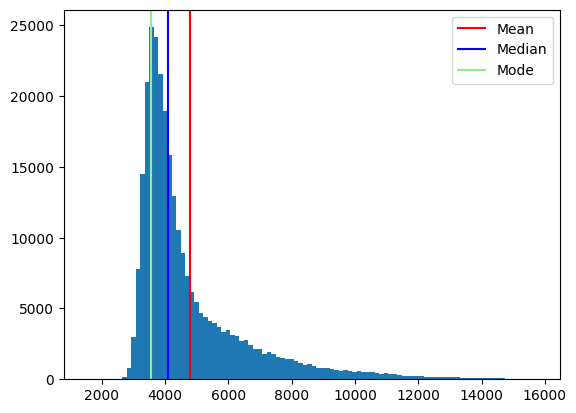

In [5]:
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats

modus = modus_result[0]

plt.hist(flat_data, bins=100)
plt.axvline(np.mean(flat_data), color='r', label='Mean')
plt.axvline(np.median(flat_data), color='blue', label='Median')
plt.axvline(modus, color='lightgreen', label='Mode')
plt.legend()
plt.show()

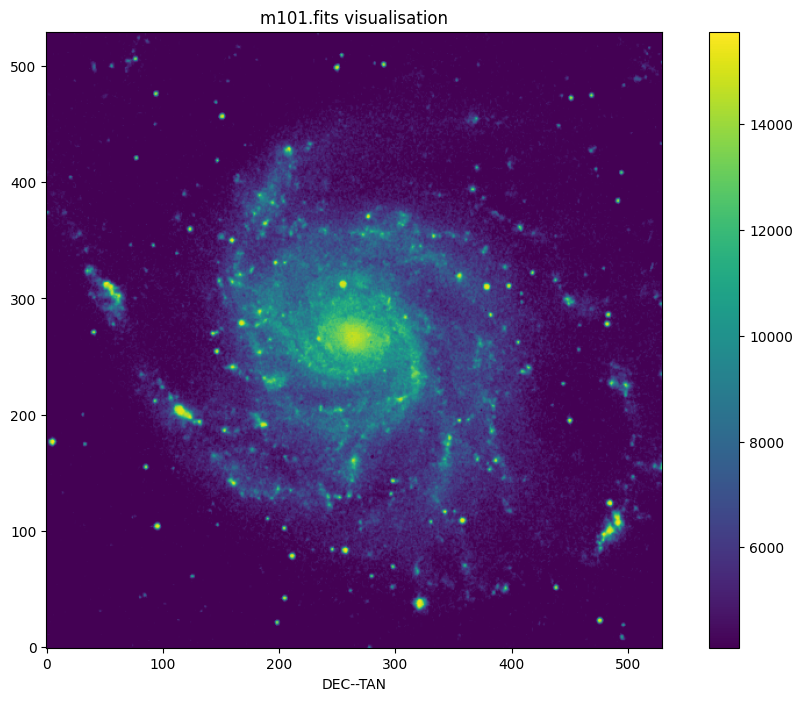

In [14]:
dat_float = np.asarray(dat, dtype=float)
fig, ax1 = plt.subplots(figsize=(12,8))
med = np.median(flat_data)

im = plt.imshow(dat_float, origin='lower', vmin =med, cmap='viridis')
plt.xlabel(hdulist[0].header.get('CTYPE1', 'X'))
plt.xlabel(hdulist[0].header.get('CTYPE2', 'Y'))
plt.title('m101.fits visualisation')
plt.colorbar(im, ax=ax1)
cbar.set_label('Counts')
plt.show()

In [ ]:
hdulist[0].header['BUNIT'] = 'Counts'
hdulist[0].data = dat_float
hdulist.writeto('m101_new.fits', overwrite=True, output_verify='silentfix')

### Q6.2

### Q6.3 (session quiz)

In [ ]:
import numpy as np
from astropy.io import fits
from matplotlib import pyplot as plt

hdulist = fits.open('/Users/users/mbweeren/PROGNUM-repo/Task6/m101.fits')
#Adding.astype(float), because the rms output would otherwise be NaN.
data = hdulist[0].data.astype(float)

#The square-shaped area between (x,y) = (100,50) and (x,y) = (120, 70) seems rather noise free to me
y, x = 100, 50
noise_slice = data[y:y+20, x:x+20]

pixels = noise_slice.flatten()
n = len(pixels)

mean = np.nanmean(pixels)
std = np.nanstd(pixels)
rms = np.sqrt(np.nanmean(pixels**2))

print(f"Mean: {mean}\n",
     f"Std: {std}\n",
     f"rms: {rms}\n")

The rms and std differ a lot since the std just says how much 68% of the data differs from the mean,while the mean root sqare also takes the mean, which is way higher than the std, into account, making it have a relatively big value.

The std quantifies noise the best, as a random value which is within one sigma of the mean will be concidered as noise, but within higher sigma multiples, considered a star. When using the rms, you dont know if a random value is just noise or a rather exceptional value which could be a potential star.

### Q6.4 (coursework)

### Q6.5 (session quiz)

In [ ]:
import numpy as np
from astropy.io import fits
from matplotlib import pyplot as plt

nm0 = fits.open('/Users/users/mbweeren/PROGNUM-repo/Task6/noisemap0.fits')
nm1 = fits.open('/Users/users/mbweeren/PROGNUM-repo/Task6/noisemap1.fits')
nm2 = fits.open('/Users/users/mbweeren/PROGNUM-repo/Task6/noisemap2.fits')

data0 = nm0[0].data.astype(float)
data1 = nm1[0].data.astype(float)
data2 = nm2[0].data.astype(float)

#Calculating std
std0 = np.nanstd(data0)
std1 = np.nanstd(data1)
std2 = np.nanstd(data2)
print(f"std0 = {std0:.3f}, std1 = {std1:.3f}, std2 = {std2:.3f}")

stacked_data = np.stack([data0, data1, data2], axis=0)
mean_image = np.mean(stacked_data, axis=0)
mean_std = np.nanstd(mean_image)

print(f"The standard deviation of the mean image:  {mean_std:.3f}")

#Theoretical std:
N = 3
th_std = (1/N) * np.sqrt(std0**2 + std1**2 + std2**2)

print(f"The theoretical standard deviation:  {th_std:.3f}")

Thus the standard deviation indeed matches the theoretical predicted value.

### Q6.6 (session quiz)

In [ ]:
from astropy.io import fits
from astropy.table import Table
import numpy as np

hdul = fits.open('/Users/users/mbweeren/PROGNUM-repo/Task6/APOGEE_stars.fits')

data = hdul[1].data 
colnames = hdul[1].columns.names #List of column names

DATAFLAG = np.where(
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'].astype(float))) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'].astype(float))) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG'].astype(float))),
    1, 0
)
print(f"Total sources:{len(DATAFLAG)}")
print(f"Sources passing quality (DATAFLAG==1): {np.sum(DATAFLAG == 1)}")
print(f"Sources failing quality (DATAFLAG==0): {np.sum(DATAFLAG == 0)}")

m_G     = data['GAIAEDR3_PHOT_G_MEAN_MAG'].astype(float)
parallax = data['GAIAEDR3_PARALLAX'].astype(float)
M_G = np.where(DATAFLAG, m_G + 5 * np.log10(parallax / 1000) + 5, -1)

t = Table(data)
t['DATAFLAG'] = DATAFLAG
t['M_G']      = M_G

t.write('APOGEE_update.fits', format='fits', overwrite=True)
hdul_new = fits.open('APOGEE_update.fits')
print("New FITS file info:")
hdul_new.info()
print(t['DATAFLAG', 'M_G'])

### Q6.7 (session quiz)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame(pd.read_csv('/Users/users/mbweeren/PROGNUM-repo/Task6/gaiaTestData.csv'))
print(df[:3])
print('...')
print()
max_flux = df['phot_g_mean_flux'].max()
print(f"Maximum value in phot_g_mean_flux: {max_flux}")

max_row = df.loc[df['phot_g_mean_flux'].idxmax()]
print(max_row)

df_sorted = df.sort_values('phot_g_mean_flux')
fig, ax = plt.subplots()
df_sorted.plot(x='phot_g_mean_flux', y='phot_g_mean_mag', kind='scatter', ax=ax)
ax.set_xlabel('phot_g_mean_flux (W m$^{-2}$ Hz$^{-1}$)')
ax.set_ylabel('phot_g_mean_mag')
plt.gca().invert_yaxis()
ax.set_title('GAIA: Flux vs Magnitude')
plt.show()

df['m0'] = df['phot_g_mean_mag'] + 2.5 * np.log10(df['phot_g_mean_flux'])
print(df['m0'])

print('Mean value of m0:', df['m0'].mean())

### Q6.8 (coursework)

### Q6.9

### Q6.10 (session quiz)

In [18]:
from astroquery.gaia import Gaia

query = """
SELECT TOP 50
    source_id, ra, dec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax / parallax_error > 5
    AND phot_g_mean_mag IS NOT NULL
    AND phot_bp_mean_mag IS NOT NULL
    AND phot_rp_mean_mag IS NOT NULL
ORDER BY random_index
"""

job = Gaia.launch_job(query)
results = job.get_results()

df = results.to_pandas()
print(df)

print(f"{df.shape}")
results.write("astroquery_gaia.fits", format = "fits", overwrite = True)

              SOURCE_ID          ra        dec  parallax  parallax_error  \
0   4267180339403392768  286.716913   0.276195  1.084924        0.033431   
1   6709252873623174016  276.691194 -46.105121  0.206682        0.040105   
2   4040949706019490560  265.229363 -36.358205  0.352725        0.029665   
3   4517539583701880064  284.025662  18.403039  0.674962        0.040008   
4   1823532754729083392  300.805804  20.601006  0.886435        0.020054   
5   3586362911238437248  171.809877 -12.086810  7.191948        0.022493   
6   2220802729771409024  320.399872  65.734951  0.289599        0.044910   
7   5850180760683762688  205.691138 -69.258740  0.541090        0.080402   
8   2128624652762622080  294.296273  47.565159  1.124423        0.092533   
9   5221499841779262720  128.012901 -71.015604  1.655686        0.183170   
10  5625161514166949120  132.768366 -37.461553  1.109231        0.201991   
11  2024051201363118080  290.025776  26.244914  0.368179        0.065745   
12  60680554

### Q6.11 (coursework)

### Q6.12 (coursework)

### Q6.13 (coursework)

### Q6.14 (session quiz)

In [ ]:
class Fibonacci:
    
    def nthterm(self, N):
        a, b = 0, 1
        for _ in range(N):
            a, b = b, a + b
        return a
    def divisiblebym(self, N, M):
        a, b = 0, 1
        n = self.nthterm(N)
        results = []
        while a < n:
            if a % M == 0:
                results.append(a)
            a, b = b, a + b
        return results

fib = Fibonacci()

N = int(input("Enter the term of the fibonacci sequence: "))
M = int(input("Enter the number you want to divide by: "))

FIB = fib.nthterm(N)
div = fib.divisiblebym(N, M)
print(f"The {N}th term is: {FIB}")
print(f"The fibonacci terms that are less than {N}th term and divisible by {M} are: {div}")